In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

# Load dataset
diabetes = load_diabetes()

# Convert to DataFrame
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)

# Display basic info
print(X.head())
print(X.describe())
print(y.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


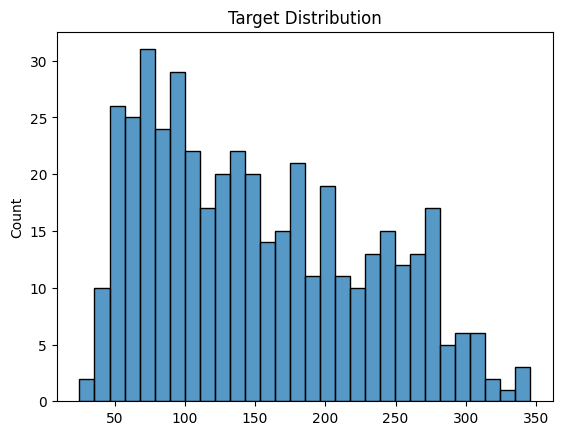

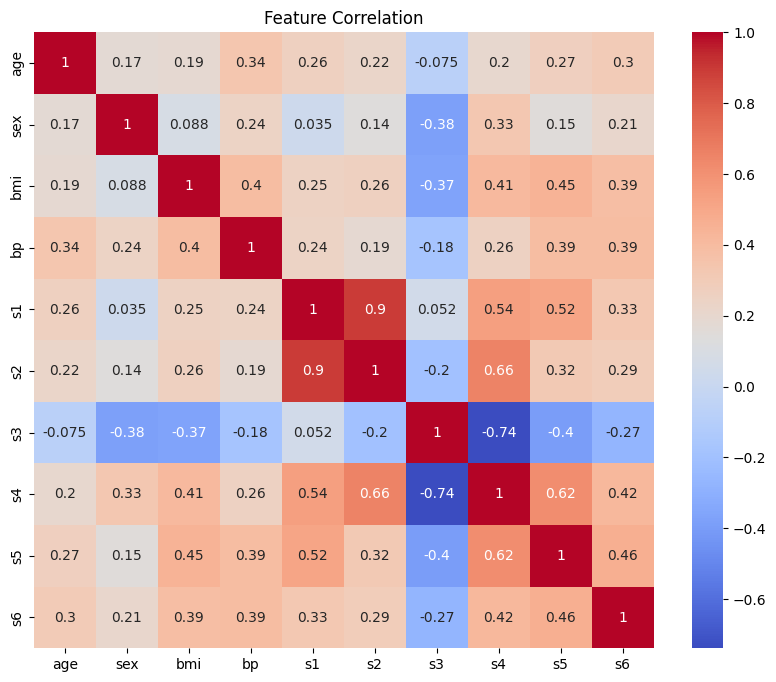

In [2]:
# Check for missing values
print(X.isnull().sum())

# Visualize distribution
sns.histplot(y, bins=30)
plt.title("Target Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

# Use one feature
X_single = X[['bmi']]

# Split
X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(mae, mse, rmse, r2)

52.25997644534553 4061.8259284949263 63.73245584860924 0.2333503981587215


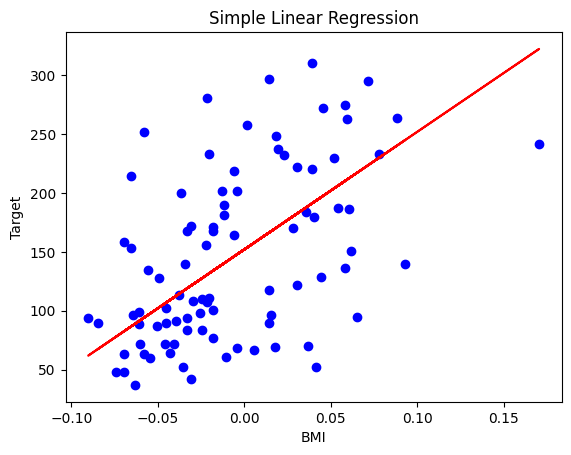

In [4]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Simple Linear Regression")
plt.show()

In [5]:
# Split full dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

# Metrics
mae = metrics.mean_absolute_error(y_test, y_pred_multi)
mse = metrics.mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred_multi)

print(mae, mse, rmse, r2)

42.794094679599944 2900.193628493483 53.85344583676594 0.45260276297191915


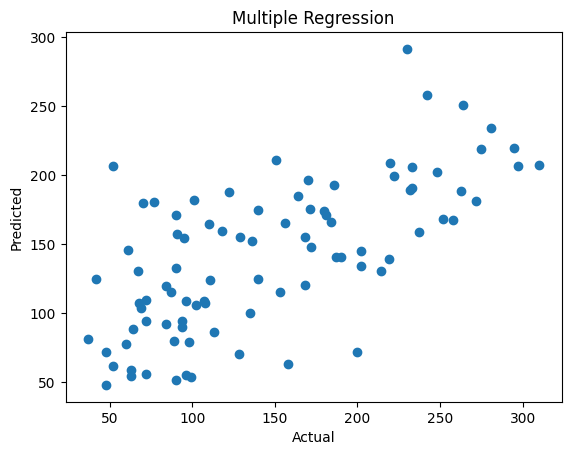

In [6]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression")
plt.show()

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

# Metrics
mae = metrics.mean_absolute_error(y_test, y_pred_poly)
mse = metrics.mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred_poly)

print(mae, mse, rmse, r2)

43.5816932546525 3096.028307344257 55.64196534401222 0.415639933640803


In [8]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Metrics function
def evaluate(y_test, y_pred):
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

print("Ridge:", evaluate(y_test, y_pred_ridge))
print("Lasso:", evaluate(y_test, y_pred_lasso))

Ridge: (46.13885766697452, 3077.41593882723, 55.47446204180109, 0.41915292635986545)
Lasso: (42.85442771664998, 2798.1934851697188, 52.897953506442185, 0.4718547867276227)


In [9]:
results = pd.DataFrame({
    "Model": ["Linear", "Multiple", "Polynomial", "Ridge", "Lasso"],
    "R2 Score": [
        metrics.r2_score(y_test, y_pred),
        metrics.r2_score(y_test, y_pred_multi),
        metrics.r2_score(y_test, y_pred_poly),
        metrics.r2_score(y_test, y_pred_ridge),
        metrics.r2_score(y_test, y_pred_lasso)
    ]
})

print(results)

        Model  R2 Score
0      Linear  0.233350
1    Multiple  0.452603
2  Polynomial  0.415640
3       Ridge  0.419153
4       Lasso  0.471855
